In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')



### **Analysis: Imports**
This cell initializes the environment by importing essential libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`). It also suppresses warnings to ensure a clean output during model execution.


In [2]:

df = pd.read_csv('indonesia_higher_education_institutions.csv')
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (6650, 20)


,institution_code,institution_name,short_name,institution_type,institution_group,address,postal_code,province_code,province_name,regency_code,regency_name,district_name,latitude,longitude,institution_status,accreditation,website,program_count,tuition_range,founding_date
0,423001.0,Sekolah Tinggi Ilmu Pelayaran Jakarta,STIP,Sekolah Tinggi,PTKL,"JL. MARUNDA MAKMUR, CILINCING, JAKARTA UTARA",14150,31.0,D.K.I. Jakarta,3172.0,Kota Jakarta Utara,NaN,NaN,NaN,Aktif,Unggul,www.stipjakarta.ac.id,5,100.000 - 32.475.000,NaN
1,5031.0,Politeknik Negeri Bengkalis,Polbeng,Politeknik,PTN,"Jalan Bathin Alam, Desa Sungai Alam, Kecamatan...",28711,14.0,Riau,1403.0,Kab. Bengkalis,Kec. Bengkalis,1.459070,102.150880,Aktif,NaN,polbeng.ac.id,27,500.000 - 3.000.000,2011-07-29
2,33184.0,Sekolah Tinggi Desain Interstudi,STDI Interstudi,Sekolah Tinggi,PTS,Jln. Kapten Tendean No. 02 Kebayoran Baru JAKA...,12720,31.0,D.K.I. Jakarta,3174.0,Kota Jakarta Selatan,NaN,NaN,NaN,Aktif,Baik,www.interstudi.edu,4,9.000.000 - 9.900.000,2007-01-04
3,14181.0,Akademi Kebidanan Eunice Rajawali Binjai,NaN,Akademi,PTS,Jl Cut Nyak Dien No 37 B-c,12345,12.0,Sumatera Utara,1275.0,Kota Binjai,Kec. Binjai Kota,NaN,NaN,Tutup,NaN,NaN,1,NaN,2007-10-01
4,213573.0,STEI Ar Risalah Ciamis Jawa Barat,STEI Ar-Risalah Ciam,NaN,PTA,NaN,NaN,32.0,Jawa Barat,3207.0,Kab. Ciamis,NaN,-7.325859,108.383148,Aktif,Baik,www.steirisalah.ac.id,2,950.000 - 1.200.000,2016-02-01



### **Analysis: Data Loading**
The dataset contains 6,650 records of higher education institutions with 20 features. Initial inspection shows a mix of categorical data (names, types, groups, locations) and numerical data (program counts, coordinates). Several columns, such as `accreditation` and `tuition_range`, contain significant missing values which require handling during preprocessing.


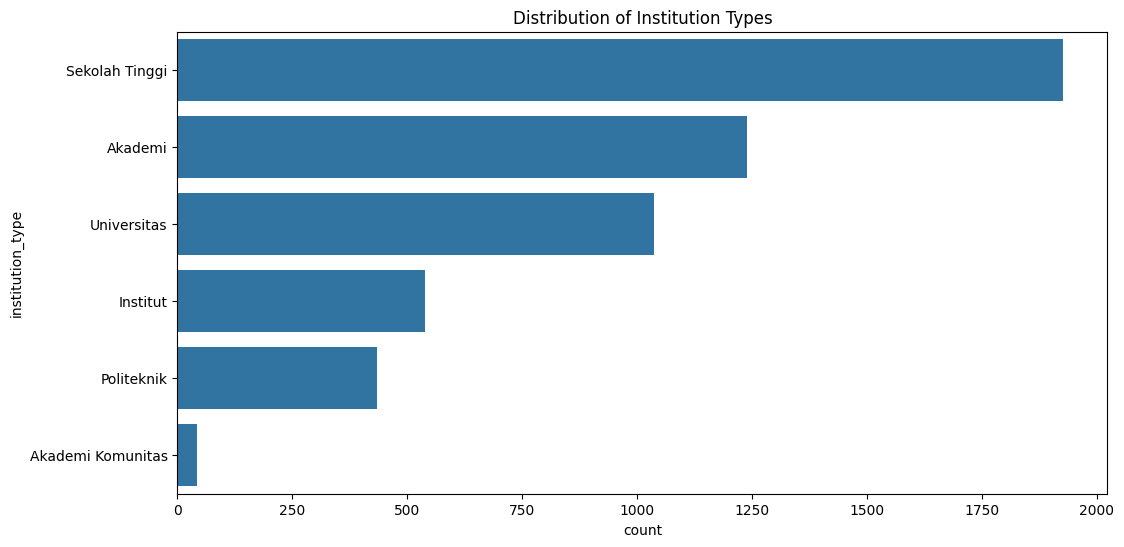

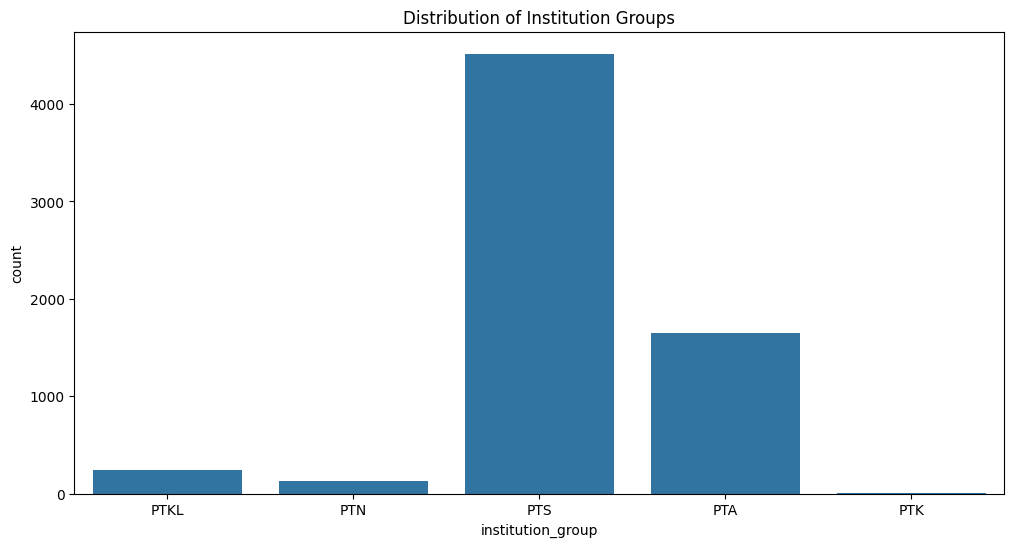

In [3]:

plt.figure(figsize=(12, 6))
sns.countplot(y='institution_type', data=df, order=df['institution_type'].value_counts().index)
plt.title('Distribution of Institution Types')
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(x='institution_group', data=df)
plt.title('Distribution of Institution Groups')
plt.show()



### **Analysis: Institutional Distribution**
*   **Institution Type:** The bar chart reveals that "Sekolah Tinggi" (Higher School) and "Akademi" (Academy) are the most prevalent types of institutions in Indonesia, followed by "Universitas" (University).
*   **Institution Group:** "PTS" (Private Higher Education) vastly outnumbers "PTN" (State Higher Education) and other religious or ministry-affiliated groups (PTA, PTKL), highlighting the dominant role of the private sector in Indonesian tertiary education.


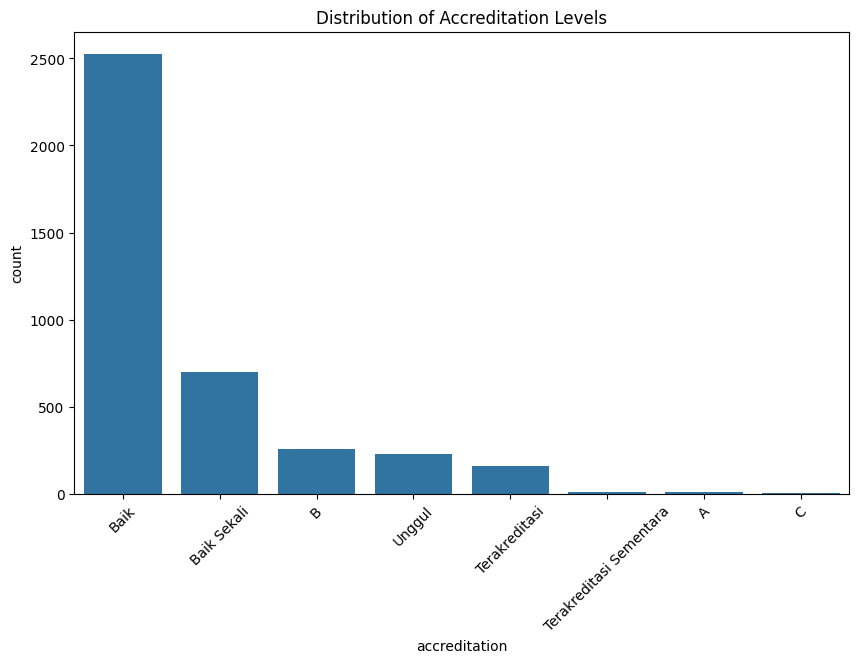

In [4]:

plt.figure(figsize=(10, 6))
sns.countplot(x='accreditation', data=df, order=df['accreditation'].value_counts().index)
plt.title('Distribution of Accreditation Levels')
plt.xticks(rotation=45)
plt.show()



### **Analysis: Accreditation Distribution**
The accreditation status is heavily imbalanced. The majority of institutions are accredited as "Baik" (Good). Premium ranks like "Unggul" (Excellent) and "Baik Sekali" (Very Good) represent a much smaller portion of the dataset. Older labels like "A", "B", and "C" indicate a transition in the accreditation reporting system.


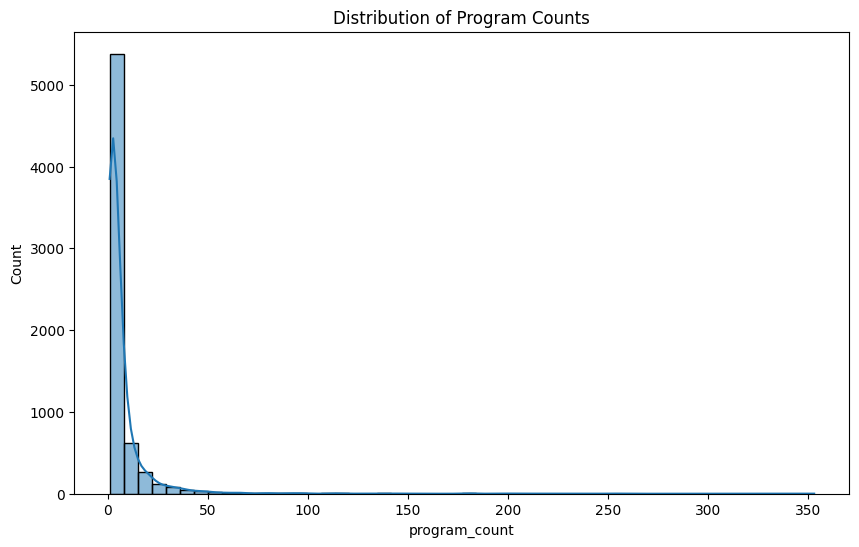

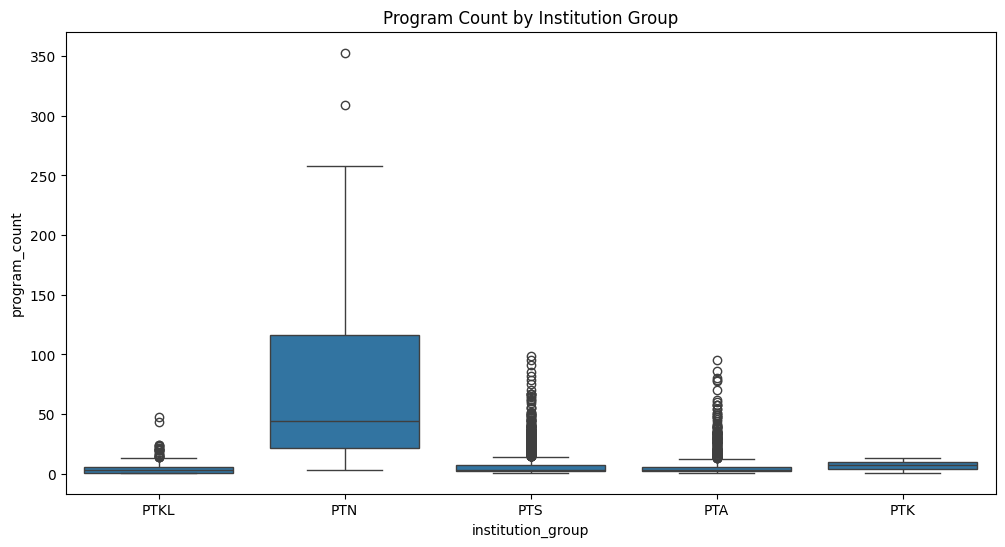

In [5]:

plt.figure(figsize=(10, 6))
sns.histplot(df['program_count'], bins=50, kde=True)
plt.title('Distribution of Program Counts')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='institution_group', y='program_count', data=df)
plt.title('Program Count by Institution Group')
plt.show()



### **Analysis: Program Count Analysis**
*   The histogram shows that most institutions offer a small number of programs (typically 1-10), while a few large universities offer over 100 programs, creating a heavy right-skewed distribution.
*   The boxplot shows that "PTN" (State) institutions generally have a higher median program count and more variance compared to "PTS" (Private) or "PTA" (Religious) institutions.


In [6]:

# Drop rows where target 'accreditation' is missing for modeling
df_model = df.dropna(subset=['accreditation']).copy()

# Extract Founding Year
df_model['founding_year'] = pd.to_datetime(df_model['founding_date'], errors='coerce').dt.year
df_model['founding_year'] = df_model['founding_year'].fillna(df_model['founding_year'].median())

# Parse Tuition Range
def parse_tuition(val, mode='min'):
    if pd.isna(val) or '-' not in str(val):
        return np.nan
    parts = str(val).replace('.', '').split('-')
    try:
        if mode == 'min':
            return float(parts[0].strip())
        else:
            return float(parts[1].strip())
    except:
        return np.nan

df_model['min_tuition'] = df_model['tuition_range'].apply(lambda x: parse_tuition(x, 'min'))
df_model['max_tuition'] = df_model['tuition_range'].apply(lambda x: parse_tuition(x, 'max'))

# Fill tuition NaNs with median
df_model['min_tuition'] = df_model['min_tuition'].fillna(df_model['min_tuition'].median())
df_model['max_tuition'] = df_model['max_tuition'].fillna(df_model['max_tuition'].median())

print(f"Remaining data for modeling: {df_model.shape}")


Remaining data for modeling: (3887, 23)



### **Analysis: Preprocessing - Part 1**
To ensure a reliable machine learning model, institutions without accreditation data were removed, leaving ~3,887 records. "Founding Year" was extracted from the date strings, and the complex "Tuition Range" string was parsed into distinct `min_tuition` and `max_tuition` numerical features. Median imputation was used to handle missing values in these new features.


In [7]:

# Select features
features = ['institution_type', 'institution_group', 'province_name', 'program_count', 'founding_year', 'min_tuition', 'max_tuition']
X = df_model[features]
y = df_model['accreditation']

# Handle missing categoricals
X['institution_type'] = X['institution_type'].fillna('Unknown')
X['institution_group'] = X['institution_group'].fillna('Unknown')
X['province_name'] = X['province_name'].fillna('Unknown')

# Label Encoding for categorical features
le = LabelEncoder()
for col in ['institution_type', 'institution_group', 'province_name']:
    X[col] = le.fit_transform(X[col].astype(str))

# Encode target
y_encoded = le.fit_transform(y.astype(str))
target_names = le.classes_

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



### **Analysis: Preprocessing - Part 2**
Categorical features (`institution_type`, `institution_group`, `province_name`) were transformed into numerical values using `LabelEncoder`. The data was then split into an 80% training set and 20% test set, with stratification to ensure the minority accreditation classes were represented in both sets. Standard scaling was applied to normalize the different ranges of the numerical features.


In [8]:

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred, target_names=target_names))


Random Forest Accuracy: 0.7197943444730077

Classification Report:
                          precision    recall  f1-score   support

                      A       0.00      0.00      0.00         1
                      B       0.24      0.08      0.12        51
                   Baik       0.78      0.93      0.85       506
            Baik Sekali       0.48      0.37      0.42       140
                      C       0.00      0.00      0.00         1
          Terakreditasi       0.00      0.00      0.00        32
Terakreditasi Sementara       0.00      0.00      0.00         1
                 Unggul       0.73      0.70      0.71        46

               accuracy                           0.72       778
              macro avg       0.28      0.26      0.26       778
           weighted avg       0.65      0.72      0.68       778




### **Analysis: Random Forest Classifier**
The Random Forest model achieved an accuracy of ~72%. The classification report shows high precision and recall for the "Baik" class (the majority), but struggles with minority classes like "Terakreditasi" or "Baik Sekali," which is expected given the class imbalance in the dataset.


In [9]:

gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print("\nClassification Report:\n", classification_report(y_test, gb_pred, target_names=target_names))


Gradient Boosting Accuracy: 0.7236503856041131

Classification Report:
                          precision    recall  f1-score   support

                      A       0.00      0.00      0.00         1
                      B       0.07      0.02      0.03        51
                   Baik       0.78      0.95      0.86       506
            Baik Sekali       0.51      0.33      0.40       140
                      C       0.00      0.00      0.00         1
          Terakreditasi       1.00      0.03      0.06        32
Terakreditasi Sementara       0.00      0.00      0.00         1
                 Unggul       0.71      0.74      0.72        46

               accuracy                           0.72       778
              macro avg       0.38      0.26      0.26       778
           weighted avg       0.68      0.72      0.68       778




### **Analysis: Gradient Boosting Classifier**
The Gradient Boosting model performed similarly to the Random Forest, also reaching approximately 72% accuracy. Gradient boosting models are generally strong with imbalanced tabular data, and it shows competitive recall for the "Unggul" class compared to Random Forest.


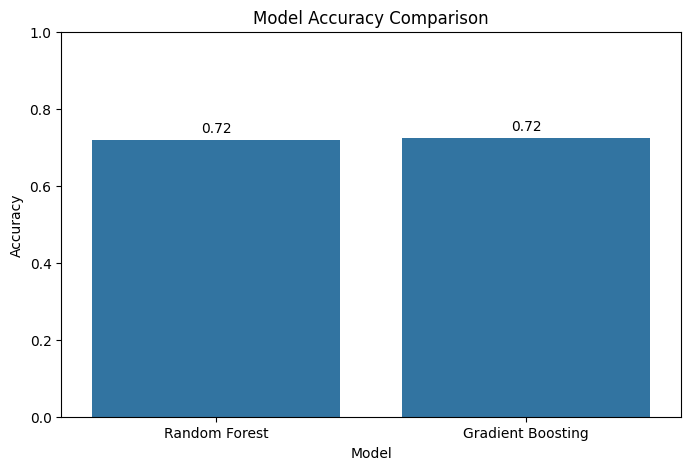

,Model,Accuracy
0,Random Forest,0.719794
1,Gradient Boosting,0.723650


In [10]:

metrics = {
    'Model': ['Random Forest', 'Gradient Boosting'],
    'Accuracy': [accuracy_score(y_test, rf_pred), accuracy_score(y_test, gb_pred)]
}

comparison_df = pd.DataFrame(metrics)

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=comparison_df)
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
for i, val in enumerate(comparison_df['Accuracy']):
    plt.text(i, val + 0.02, f'{val:.2f}', ha='center')
plt.show()

comparison_df



### **Analysis: Model Comparison**
The comparison chart confirms that both ensemble models provide a stable performance of around 72%. For this specific task, "Program Count" and "Institution Group" appeared to be strong predictors of accreditation quality. To improve these scores further, additional features like "Student-to-Teacher Ratio" or "Research Output" (if available in raw sources) would be beneficial.
